현제 23데이터셋의 demo_data\sub-001\ses-001\eeg\sub-001_ses-001_task-sleep_eeg 기준
바꿨던 부분(17과 동일) 
모든 모델 설정파일에 쓰는 신호의 개수와 사용하는 부분만 활성화 config.json(설정파일): 
config['BAS_CHANNELS'] = 6#기본신호 개수
config['RESP_CHANNELS'] = 0#호홉신호 개수
config['EKG_CHANNELS'] = 0#심전도 개수
config['EMG_CHANNELS'] = 0#근전도 개수
config['modality_types'] = ['BAS']#지금 사용하는 부분만

channel_groups 객체 수정 (또는 json 파일 수정)
channel_groups = {
    "BAS": ["C3", "O1", "F3", "C4", "O2", "F4"], # 사용 중인 두피 EEG 채널
    "RESP": [],  # 키가 없으면 KeyError가 나므로 빈 리스트로 명시
    "EKG": [],
    "EMG": []
}

신호
sub-001_ses-001_task-sleep_acq-PSG_eeg.set 파일-> edf->hdf5
수면단계
sub-001_ses-001_task-sleep_acq-scoring_events.tsv->csv

예상가능한 문제점
tsv는 30초간격으로 상태를 확인, csv는 5초간격으로 줘야 되서, 30초를 5초 간격으로 분할시켜서 저장함
이로 인해 정확하지 않은 라벨이 들어감

#### Note: All data in this repo is synthetically made including sleep stage annotations, demographics or diseases. The data is for demo purposes only.


참고: 이 저장소의 모든 데이터(수면 단계 주석, 인구통계학적 정보, 질병 정보 등 포함)는 합성 방식으로 생성되었습니다. 이 데이터는 오직 시연 목적으로만 사용됩니다.

In [1]:
import pyedflib

In [2]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("Device Count:", torch.cuda.device_count())

CUDA Available: True
Device Count: 1


In [3]:
%load_ext autoreload 
%autoreload 2

#### Preprocessing Details


Before running this notebook, please preprocess your PSG files using the scripts provided in `sleepfm/preprocessing`. Note that PSG recordings may contain different sets of channels across datasets. The predefined channel–modality mappings used in this project are specified in `sleepfm/configs/channel_groups.json`.

Although we have attempted to make this mapping as comprehensive as possible, we strongly recommend reviewing the channels present in your specific PSG data. In consultation with domain experts, you should group any additional or dataset-specific channels into the appropriate modality categories and update `channel_groups.json` accordingly. This step is critical to ensure that all channels are correctly aligned with their intended modalities during preprocessing and downstream modeling.

전처리 관련 상세 사항
이 노트북을 실행하기 전에 `sleepfm/preprocessing`에 제공된 스크립트를 사용하여 PSG 파일을 전처리해 주십시오. 데이터셋마다 PSG 기록에 포함된 채널 구성이 다를 수 있다는 점에 유의해야 합니다. 본 프로젝트에서 사용하는 사전 정의된 채널-모달리티(channel-modality) 매핑 정보는 `sleepfm/configs/channel_groups.json`에 명시되어 있습니다.

저희는 가능한 한 포괄적인 매핑을 구성하고자 노력했으나, 사용하시는 특정 PSG 데이터에 포함된 채널을 직접 검토해 보실 것을 강력히 권장합니다. 도메인 전문가와 상의하여 추가적인 채널이나 특정 데이터셋 고유의 채널을 적절한 모달리티 범주로 분류하고, 이에 맞춰 `channel_groups.json`을 업데이트해야 합니다. 이 과정은 전처리 및 이후 모델링 단계에서 모든 채널이 의도된 모달리티와 올바르게 매칭되도록 하는 데 있어 매우 중요합니다.

In [4]:
import torch #토치
from torch import nn #신경망레이어
import numpy as np #
from sklearn.metrics import f1_score, confusion_matrix
import os
import tqdm
import random
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from collections import Counter
import pandas as pd
sys.path.append("..")
sys.path.append("../sleepfm")
from preprocessing.preprocessing import EDFToHDF5Converter
from models.dataset import SetTransformerDataset, collate_fn
from models.models import SetTransformer, SleepEventLSTMClassifier, DiagnosisFinetuneFullLSTMCOXPHWithDemo
import h5py
from utils import load_config, load_data, save_data, count_parameters
from torch.utils.data import Dataset, DataLoader

#### Part 0: Preprocessing EDF files

Note: This is just a demo notebook that preprocesses a single, specific file. run `sleepfm/preprocessing/preprocessing.sh` with appropriate folders to generate multiple preprocessed files.

파트 0: EDF 파일 전처리
참고: 이는 단일 특정 파일을 전처리하는 데 사용되는 데모용 노트북입니다. 
여러 개의 전처리된 파일을 생성하려면 적절한 폴더 경로를 지정하여 `sleepfm/preprocessing/preprocessing.sh`를 실행하십시오.

In [5]:
base_save_path = "demo_data\EESM23\sub-001\ses-001\eeg"
os.makedirs(base_save_path, exist_ok=True)#지정한 경로("demo_data")에 폴더를 생성합니다.

In [6]:
import mne
base_set_path = base_save_path+"\sub-001_ses-001_task-sleep_acq-PSG_eeg.set"
raw = mne.io.read_raw_eeglab(base_set_path, preload=False)
print(raw.ch_names) 

C:\Users\user\AppData\Local\Temp\ipykernel_35036\3539714344.py:3: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  raw = mne.io.read_raw_eeglab(base_set_path, preload=False)


['EOGr', 'EOGl', 'EMGl', 'EMGr', 'M1', 'F3', 'C3', 'O1', 'M2', 'F4', 'C4', 'O2', 'EMGc']


In [58]:
base_set_path = base_save_path+"\sub-001_ses-001_task-sleep_acq-PSG_eeg.set"
edf_output_path = base_save_path+"\sub-001_ses-001_task-sleep_acq-PSG_eeg.edf"
input_tsv = os.path.join(base_save_path, "sub-001_ses-001_task-sleep_acq-scoring_events.tsv")
tsv_df = pd.read_csv(input_tsv, sep='\t')
tsv_df2 = tsv_df.sort_values('onset').reset_index(drop=True)
first_onset = float(tsv_df2.iloc[0]['onset'])

raw = mne.io.read_raw_eeglab(base_set_path, preload=True)
first_onset = first_onset  # TSV 파일의 첫 번째 onset 값(초)

# 3. 신호 데이터의 시작 지점을 first_onset 이후로 잘라냄 (Crop)
raw.crop(tmin=first_onset, tmax=None)
target_channels = ['F3', 'C3', 'O1', 'F4', 'C4', 'O2']
raw.pick_channels(target_channels)

# mne.export.export_raw(edf_output_path, raw, fmt='edf', overwrite=True)
# 2. [에러 해결 핵심] 데이터 내부의 NaN 및 Inf 값 정제
# raw._data Tensor/Array의 NaN과 Inf 값을 0.0으로 대체합니다.
data = raw.get_data() # shape: [channels, time_samples]

if np.isnan(data).any() or np.isinf(data).any():
    print("경고: 신호 데이터 내에 NaN 또는 Inf 값 발견. 선형 보간(Interpolation)으로 보정합니다.")
    
    # 1. Inf 값을 먼저 NaN으로 대체
    data[np.isinf(data)] = np.nan
    
    # 2. 각 채널(행)별로 선형 보간 수행
    for ch_idx in range(data.shape[0]):
        ch_data = data[ch_idx]
        if np.isnan(ch_data).any():
            # pandas Series의 interpolate 활용 (앞/뒤 값으로 연결)
            s = pd.Series(ch_data)
            # both 방향으로 보간하여 양 끝단의 NaN까지 처리
            s = s.interpolate(method='linear', limit_direction='both')
            # 만약 양 끝단 전체가 NaN인 경우를 대비해 0으로 채움
            data[ch_idx] = s.fillna(0.0).to_numpy()

    # 3. 보정된 데이터를 raw 객체에 업데이트
    raw._data = data

# 3. .EDF 파일로 저장 (Export)
mne.export.export_raw(edf_output_path, raw, fmt='edf', overwrite=True)
print(f"변환 완료! 파일이 저장되었습니다: {edf_output_path}")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
경고: 신호 데이터 내에 NaN 또는 Inf 값 발견. 선형 보간(Interpolation)으로 보정합니다.
Overwriting existing file.


C:\Users\user\AppData\Local\Temp\ipykernel_35036\718239444.py:42: RuntimeWarning: EDF format requires equal-length data blocks, so 0.076 seconds of zeros were appended to all channels when writing the final block.
  mne.export.export_raw(edf_output_path, raw, fmt='edf', overwrite=True)


변환 완료! 파일이 저장되었습니다: demo_data\EESM23\sub-001\ses-001\eeg\sub-001_ses-001_task-sleep_acq-PSG_eeg.edf


In [59]:
import matplotlib.pyplot as plt
from pyedflib import highlevel

# edf_path = "base_save_path+"\sub-001_ses-001_task-sleep_acq-PSG_eeg.edf""
edf_path=edf_output_path
a = highlevel.read_edf(edf_path)
print(a)

(array([[ 3.11136761e+04,  3.11182841e+04,  3.11182841e+04, ...,
         4.77820673e-01,  4.77820673e-01,  4.77820673e-01],
       [-6.47971813e+04, -6.47879653e+04, -6.47879653e+04, ...,
         4.77820673e-01,  4.77820673e-01,  4.77820673e-01],
       [-8.06579082e+04, -8.06486922e+04, -8.06440842e+04, ...,
         4.77820673e-01,  4.77820673e-01,  4.77820673e-01],
       [-6.69767640e+04, -6.69675480e+04, -6.69675480e+04, ...,
         4.77820673e-01,  4.77820673e-01,  4.77820673e-01],
       [-9.91593253e+03, -9.90671654e+03, -9.90210854e+03, ...,
         4.77820673e-01,  4.77820673e-01,  4.77820673e-01],
       [-1.71643124e+04, -1.71550964e+04, -1.71504884e+04, ...,
         4.77820673e-01,  4.77820673e-01,  4.77820673e-01]]), [{'label': 'F3', 'dimension': 'uV', 'sample_rate': 250.0, 'sample_frequency': 250.0, 'physical_max': 199835.5, 'physical_min': -102145.0, 'digital_max': 32767, 'digital_min': -32767, 'prefilter': 'HP:0.0Hz LP:125.0Hz', 'transducer': ''}, {'label': 'C3',

[{'label': 'C3-A2', 'dimension': 'V', 'sample_rate': 256.0, 'sample_frequency': 256.0, 'physical_max': 5e-06, 'physical_min': 0.0, 'digital_max': 32767, 'digital_min': -32768, 'prefilter': '', 'transducer': ''}, 
{'label': 'Airflow', 'dimension': 'V', 'sample_rate': 256.0, 'sample_frequency': 256.0, 'physical_max': 5e-06, 'physical_min': 0.0, 'digital_max': 32767, 'digital_min': -32768, 'prefilter': '', 'transducer': ''}, 
{'label': 'Arm EMG', 'dimension': 'V', 'sample_rate': 256.0, 'sample_frequency': 256.0, 'physical_max': 4e-06, 'physical_min': 0.0, 'digital_max': 32767, 'digital_min': -32768, 'prefilter': '', 'transducer': ''}, 
{'label': 'EKG', 'dimension': 'V', 'sample_rate': 256.0, 'sample_frequency': 256.0, 'physical_max': 4e-06, 'physical_min': 0.0, 'digital_max': 32767, 'digital_min': -32768, 'prefilter': '', 'transducer': ''}], 

{'technician': '', 'recording_additional': '', 'patientname': 'X', 'patient_additional': '', 'patientcode': '', 'equipment': '', 'admincode': '', 'sex': '', 'startdate': datetime.datetime(2026, 1, 5, 23, 27, 5), 'birthdate': '', 'gender': '', 'annotations': []})


📊 [EDF 파일 기본 요약 정보]
• 기록 시작 시간 : 1985-01-01 00:00:00
• 환자 ID/이름   : X

⚙️ [채널별 수면다원검사(PSG) 구성 의미]
• 총 기록 시간   : 23645.00초 (약 394.1분)
• 채널 수         : 6 개

[1] F3 (생체 신호 채널)
    - 샘플링 레이트 : 250.0 Hz (1초에 250번 측정)
    - 단위 및 진폭   : uV (최대 199835.5V ~ 최소 -102145.0V)
    - 데이터 개수   : 5911250 samples

[2] C3 (생체 신호 채널)
    - 샘플링 레이트 : 250.0 Hz (1초에 250번 측정)
    - 단위 및 진폭   : uV (최대 199835.5V ~ 최소 -102145.0V)
    - 데이터 개수   : 5911250 samples

[3] O1 (생체 신호 채널)
    - 샘플링 레이트 : 250.0 Hz (1초에 250번 측정)
    - 단위 및 진폭   : uV (최대 199835.5V ~ 최소 -102145.0V)
    - 데이터 개수   : 5911250 samples

[4] F4 (생체 신호 채널)
    - 샘플링 레이트 : 250.0 Hz (1초에 250번 측정)
    - 단위 및 진폭   : uV (최대 199835.5V ~ 최소 -102145.0V)
    - 데이터 개수   : 5911250 samples

[5] C4 (생체 신호 채널)
    - 샘플링 레이트 : 250.0 Hz (1초에 250번 측정)
    - 단위 및 진폭   : uV (최대 199835.5V ~ 최소 -102145.0V)
    - 데이터 개수   : 5911250 samples

[6] O2 (생체 신호 채널)
    - 샘플링 레이트 : 250.0 Hz (1초에 250번 측정)
    - 단위 및 진폭   : uV (최대 199835.5V ~ 최소 -102145.0V)
    - 데이터 개수   : 5911

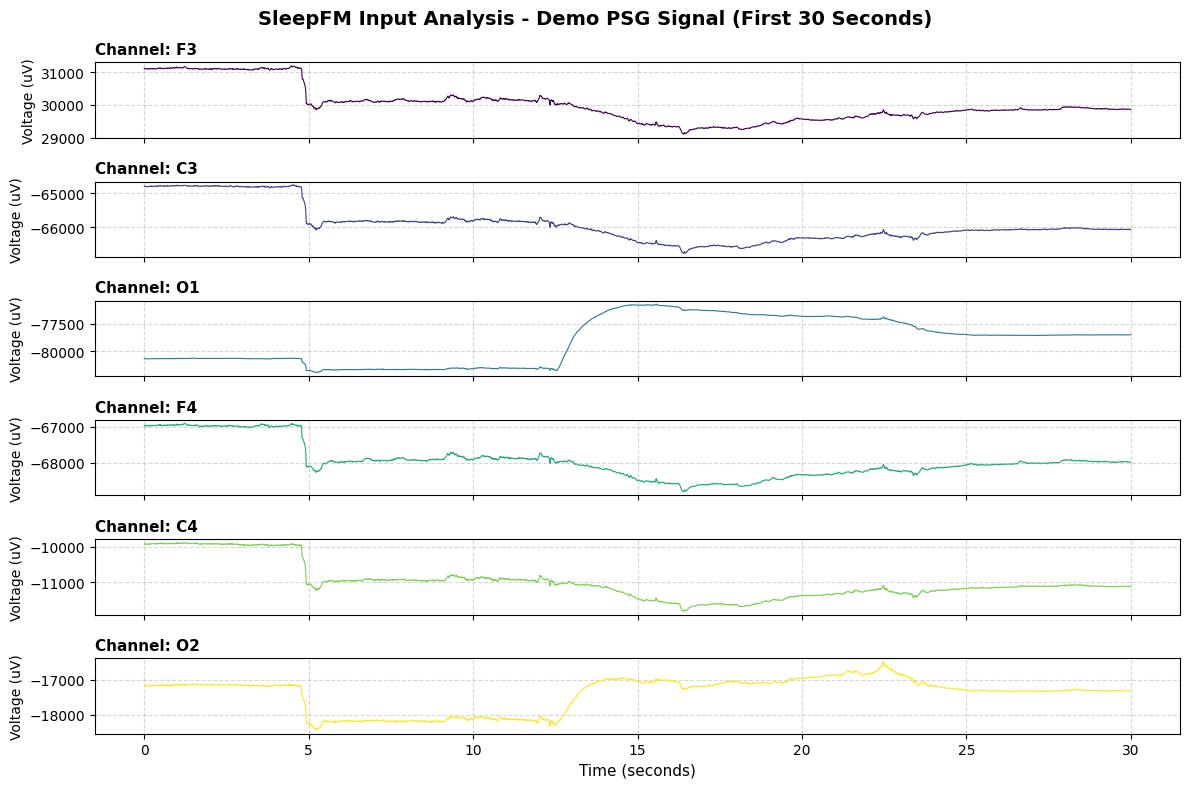

In [60]:
import datetime
import matplotlib.pyplot as plt
from pyedflib import highlevel
import matplotlib.colors as mcolors

def generate_colors(n, cmap_name='viridis'):
    """
    지정한 개수(n)만큼 Matplotlib 컬러맵에서 16진수 색상 리스트를 생성합니다.
    자주 쓰이는 컬러맵: 'viridis', 'plasma', 'inferno', 'tab10', 'rainbow'
    """
    cmap = plt.colormaps[cmap_name]
    
    # 0부터 1 사이를 n등분하여 컬러맵에서 색상을 추출
    colors = [cmap(i / (n - 1)) if n > 1 else cmap(0) for i in range(n)]
    
    # Matplotlib의 RGBA 색상을 16진수(Hex) 코드로 변환
    hex_colors = [mcolors.to_hex(c) for c in colors]
    return hex_colors


# 1. 데이터 불러오기
# edf_path = "demo_data/demo_psg.edf"
edf_path=edf_output_path
signals, channel_headers, file_header = highlevel.read_edf(edf_path)

# =================================================================
# [분석 1] 메타데이터 및 전체적인 의미 해석 (텍스트 출력)
# =================================================================
print("=" * 60)
print(f"📊 [EDF 파일 기본 요약 정보]")
print("=" * 60)
print(f"• 기록 시작 시간 : {file_header.get('startdate')}")
print(f"• 환자 ID/이름   : {file_header.get('patientname')}")

print("\n⚙️ [채널별 수면다원검사(PSG) 구성 의미]")
total_samples = len(signals[0])
sample_rate = channel_headers[0]['sample_rate']
total_seconds = total_samples / sample_rate

print(f"• 총 기록 시간   : {total_seconds:.2f}초 (약 {total_seconds/60:.1f}분)")
print(f"• 채널 수         : {len(signals)} 개")

# 채널별 세부 정보 해석

for i, ch in enumerate(channel_headers):
    label = ch['label']
    meaning = "생체 신호 채널"
    print(f"\n[{i+1}] {label} ({meaning})")
    print(f"    - 샘플링 레이트 : {ch['sample_rate']} Hz (1초에 {int(ch['sample_rate'])}번 측정)")
    print(f"    - 단위 및 진폭   : {ch['dimension']} (최대 {ch['physical_max']}V ~ 최소 {ch['physical_min']}V)")
    print(f"    - 데이터 개수   : {len(signals[i])} samples")

# =================================================================
# [분석 2] 생체 신호 데이터 시각화 (첫 30초 구간 확인)
# =================================================================
# 수면 다원 검사의 표준 판독 단위인 '30초(Epoch)'를 기준으로 시각화합니다.
view_seconds = 30  
num_samples_to_plot = int(view_seconds * sample_rate)

# X축 시간 데이터 생성 (0초부터 30초까지)
time_axis = [t / sample_rate for t in range(num_samples_to_plot)]

# 4개 채널을 각각 그리기 위한 그래프 틀 생성
fig, axes = plt.subplots(nrows=len(signals), ncols=1, figsize=(12, 8), sharex=True)
fig.suptitle("SleepFM Input Analysis - Demo PSG Signal (First 30 Seconds)", fontsize=14, fontweight='bold')

# 각 채널의 데이터를 하나씩 그래프로 매핑
colors = generate_colors(len(signals), cmap_name='viridis') 

for i, ch in enumerate(channel_headers):
    label = ch['label']
    unit = ch['dimension']
    
    # 30초 분량만큼 데이터 슬라이싱
    signal_data = signals[i][:num_samples_to_plot]
    
    # 서브플롯 그리기
    axes[i].plot(time_axis, signal_data, color=colors[i], linewidth=0.8)
    axes[i].set_title(f"Channel: {label}", fontsize=11, loc='left', fontweight='bold')
    axes[i].set_ylabel(f"Voltage ({unit})")
    axes[i].grid(True, linestyle='--', alpha=0.5)

# 최하단 X축 설정
axes[-1].set_xlabel("Time (seconds)", fontsize=11)
plt.tight_layout()
plt.show()


In [61]:
root_dir = base_save_path+"\edf_root"      # 여러 파일을 일괄 변환할 때 사용할 더미(Dummy) 원본 디렉터리 경로를 설정합니다. (단일 파일 변환에서는 사용되지 않음)
target_dir = base_save_path+"\note"    # 여러 파일을 일괄 변환할 때 사용할 더미 Target 디렉터리 경로를 설정합니다. (단일 파일 변환에서는 사용되지 않음)

edf_path = edf_output_path #변환할 원본 EDF(European Data Format) 수면 다원 검사 파일의 경로를 지정합니다.
hdf5_path = os.path.join(base_save_path, "demo_psg.hdf5") #변환 결과를 저장할 HDF5 파일 경로를 만듭니다. 이전 단계의 base_save_path("demo_data")와 파일명을 결합하여 "demo_data/demo_psg.hdf5"라는 경로가 생성됩니다.

converter = EDFToHDF5Converter(
    root_dir=root_dir,
    target_dir=target_dir,
    resample_rate=128
)#앞서 불러온 EDFToHDF5Converter 클래스의 인스턴스(객체)를 생성합니다.

# run for single file conversion
converter.convert(edf_path, hdf5_path) #실제로 단일 EDF 파일(edf_path)을 읽어와 128Hz 리샘플링 및 HDF5 포맷 변환을 수행한 뒤, 지정한 경로(hdf5_path)에 저장합니다.

2026-09-21 11:21:10.665 | INFO     | preprocessing.preprocessing:read_edf:146 - reading edf


Extracting EDF parameters from C:\Users\user\sleep_fm_r\notebooks\demo_data\EESM23\sub-001\ses-001\eeg\sub-001_ses-001_task-sleep_acq-PSG_eeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 5911249  =      0.000 ... 23644.996 secs...


C:\Users\user\sleep_fm_r\notebooks\../sleepfm\preprocessing\preprocessing.py:147: RuntimeWarning: Omitted 3 annotation(s) that were outside data range.
  raw = mne.io.read_raw_edf(file_path, preload=True)
2026-09-21 11:21:11.079 | INFO     | preprocessing.preprocessing:resample_signals:184 - resampling signals


Filtering signal
Filtering signal
Filtering signal
Filtering signal
Filtering signal
Filtering signal


2026-09-21 11:21:12.084 | INFO     | preprocessing.preprocessing:save_to_hdf5:219 - saving hdf5


#### Part 1: Generating embeddings from SleepFM pretrained model

Here we show generating embedding for 1 demno PSG. To see full script, please check `sleepfm/pipeline/generate_embeddings.py`. 

파트 1: SleepFM 사전 학습 모델을 이용한 임베딩 생성
여기서는 데모용 PSG 데이터 1개에 대한 임베딩 생성 과정을 보여줍니다. 전체 스크립트는 `sleepfm/pipeline/generate_embeddings.py`에서 확인하실 수 있습니다.

In [62]:
model_path = "../sleepfm/checkpoints/model_base"#사전 학습된 모델 체크포인트 파일들이 들어 있는 기본 폴더 경로를 지정합니다.
channel_groups_path = "../sleepfm/configs/channel_groups.json"#수면 다원 검사 신호(EEG, ECG, EMG 등)의 채널 묶음 정보가 정의된 JSON 파일 경로를 지정합니다.
config_path = os.path.join(model_path, "config.json")#model_path 경로와 파일명을 안전하게 결합하여 모델 설정 파일 경로인 "../sleepfm/checkpoints/model_base/config.json"을 만듭니다.

config = load_config(config_path)#앞서 만든 경로(config_path)의 설정 파일(JSON 또는 YAML 등)을 읽어와 모델 구조, 하이퍼파라미터 등이 담긴 config 객체/딕셔너리로 저장합니다.
channel_groups = load_data(channel_groups_path)#채널 그룹 설정 파일(channel_groups_path)을 읽어와 각 생체 신호 채널의 매핑 정보를 channel_groups 변수에 저장합니다.

In [63]:
#이부분은 json 자체를 변경시키는 게 나음(경로: ../sleepfm/checkpoints/model_base/config.json)
config['BAS_CHANNELS'] = 6
config['RESP_CHANNELS'] = 0
config['EKG_CHANNELS'] = 0
config['EMG_CHANNELS'] = 0
config['modality_types'] = ['BAS']

# MNE 전처리 시 128Hz로 리샘플링하지 않고 원본 200Hz를 그대로 쓴다면:
# config['sampling_freq'] = 200 

# 2. channel_groups 객체 수정 (또는 json 파일 수정)
channel_groups = {
    "BAS": ["C3", "O1", "F3", "C4", "O2", "F4"], # 사용 중인 두피 EEG 채널
    "RESP": [],  # 키가 없으면 KeyError가 나므로 빈 리스트로 명시
    "EKG": [],
    "EMG": []
}

In [64]:
print(config)

{'seed': 42, 'model': 'SetTransformer', 'in_channels': 1, 'batch_size': 128, 'epochs': 1, 'lr': 0.001, 'lr_step_period': 2, 'gamma': 0.1, 'temperature': 0.0, 'momentum': 0.9, 'num_workers': 16, 'embed_dim': 128, 'num_heads': 8, 'num_layers': 6, 'pooling_head': 8, 'dropout': 0.3, 'split_path': 'path_to_/dataset_split.json', 'save_path': 'path_to_/models', 'weight_decay': 0.0, 'mode': 'leave_one_out', 'save_iter': 5000, 'eval_iter': 5000, 'log_interval': 100, 'use_wandb': True, 'BAS_CHANNELS': 6, 'RESP_CHANNELS': 0, 'EKG_CHANNELS': 0, 'EMG_CHANNELS': 0, 'max_files': None, 'val_size': 100, 'sampling_duration': 5, 'sampling_freq': 128, 'patch_size': 640, 'modality_types': ['BAS']}


{'seed': 42, 'model': 'SetTransformer', 'in_channels': 1, 'batch_size': 128, 'epochs': 1, 
'lr': 0.001, 'lr_step_period': 2, 'gamma': 0.1, 'temperature': 0.0, 'momentum': 0.9, 
'num_workers': 16, 'embed_dim': 128, 'num_heads': 8, 'num_layers': 6, 'pooling_head': 8, 
'dropout': 0.3, 'split_path': 'path_to_/dataset_split.json', 'save_path': 'path_to_/models', 'weight_decay': 0.0, 'mode': 'leave_one_out', 'save_iter': 5000, 'eval_iter': 5000, 'log_interval': 100, 'use_wandb': True, 'BAS_CHANNELS': 10, 
'RESP_CHANNELS': 7, 'EKG_CHANNELS': 2, 'EMG_CHANNELS': 4, 'max_files': None, 'val_size': 100, 
'sampling_duration': 5, 'sampling_freq': 128, 'patch_size': 640, 'modality_types': ['BAS', 'RESP', 'EKG', 'EMG']}

In [65]:
modality_types = config["modality_types"]#모델이 입력받는 생체 신호 모달리티(양식)의 종류(예: EEG, ECG, EMG 등) 리스트를 가져옵니다.
in_channels = config["in_channels"]#각 신호 모달리티별 입력 채널의 개수(또는 차원)를 가져옵니다.
patch_size = config["patch_size"]#트랜스포머 입력으로 사용하기 위해 시계열 신호를 잘라내는 패치(Patch)의 크기/길이를 가져옵니다.
embed_dim = config["embed_dim"]#트랜스포머 내부에서 신호 데이터를 표현할 임베딩 차원의 크기(Embedding Dimension)를 가져옵니다.
num_heads = config["num_heads"]#트랜스포머의 Multi-Head Attention 연산에서 사용할 헤드(Head)의 개수를 가져옵니다.
num_layers = config["num_layers"]#트랜스포머 인코더/블록을 위로 몇 층(Layer) 쌓을 것인지 레이어 개수를 가져옵니다.
pooling_head = config["pooling_head"]#시계열/채널 차원의 피처들을 하나로 압축할 때 사용할 풀링(Pooling) 방식 및 풀링 헤드 관련 설정을 가져옵니다.
dropout = 0.0#학습이나 추론 시 신경망 내 노드를 임의로 비활성화하는 드롭아웃(Dropout) 비율을 0.0(0%)으로 지정합니다. (추론/평가 단계이므로 드롭아웃을 적용하지 않음)

modality_types = ['BAS', 'RESP', 'EKG', 'EMG']#모델이 입력받는 생체 신호 모달리티(양식)의 종류(예: EEG, ECG, EMG 등) 리스트를 가져옵니다.
in_channels = 1#각 신호 모달리티별 입력 채널의 개수(또는 차원)를 가져옵니다.
patch_size = 640#트랜스포머 입력으로 사용하기 위해 시계열 신호를 잘라내는 패치(Patch)의 크기/길이를 가져옵니다.
embed_dim = 128#트랜스포머 내부에서 신호 데이터를 표현할 임베딩 차원의 크기(Embedding Dimension)를 가져옵니다.
num_heads = 8#트랜스포머의 Multi-Head Attention 연산에서 사용할 헤드(Head)의 개수를 가져옵니다.
num_layers = 6#트랜스포머 인코더/블록을 위로 몇 층(Layer) 쌓을 것인지 레이어 개수를 가져옵니다.
pooling_head = 8#시계열/채널 차원의 피처들을 하나로 압축할 때 사용할 풀링(Pooling) 방식 및 풀링 헤드 관련 설정을 가져옵니다.

In [66]:
model_class = getattr(sys.modules[__name__], config['model'])#config['model']에 적힌 문자열(예: "SetTransformer")을 바탕으로 현재 스코프에 임포트된 클래스 객체를 동적으로 가져옵니다.
#SetTransformer
model = model_class(in_channels, patch_size, embed_dim, num_heads, num_layers, pooling_head=pooling_head, dropout=dropout)
#가져온 모델 클래스(model_class)에 앞서 설정한 하이퍼파라미터들을 전달하여 실제로 인스턴스화(생성)합니다.
# Use GPU if available, otherwise default to CPU safely

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#GPU(CUDA)를 사용할 수 있으면 "cuda", 그렇지 않으면 "cpu"를 선택하여 연산 장치(device)로 지정합니다.
model = model.to(device)
#생성한 모델을 지정한 연산 장치(GPU 또는 CPU)의 메모리로 이동시킵니다.

if device.type == "cuda" and torch.cuda.device_count() > 1:#현재 장치가 GPU이고, 사용 가능한 GPU 개수가 2개 이상인지 확인하는 조건문입니다.
    model = torch.nn.DataParallel(model)
#여러 개의 GPU가 있을 경우, 데이터를 병렬로 나누어 연산할 수 있도록 모델을 DataParallel로 감쌉니다.

model.to(device)
#DataParallel 적용 후 모델을 다시 해당 연산 장치에 확실하게 할당합니다.

total_layers, total_params = count_parameters(model)
#앞서 가져온 유틸리티 함수 count_parameters를 이용해 모델의 전체 레이어 수와 파라미터 수를 계산합니다.

print(f'Trainable parameters: {total_params / 1e6:.2f} million')
#학습 가능한 파라미터 수(total_params)를 백만(1e6) 단위로 나누어 소수점 둘째 자리까지 출력합니다.
print(f'Number of layers: {total_layers}')
#모델의 총 레이어 개수를 출력합니다.

Trainable parameters: 4.44 million
Number of layers: 93


C:\Users\user\anaconda3\envs\sleepfm_env\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [67]:
checkpoint = torch.load(os.path.join(model_path, "best.pt"), weights_only=False)#모델 불러오기
state_dict = checkpoint["state_dict"]#모델레이어이름과 자중치가 있는 데이터 불러오기

# module. 접두사 제거
new_state_dict = {}#새로운 가중치 파라미터들을 담아둘 빈 딕셔너리를 생성합니다.
for k, v in state_dict.items():#레이어 이름과 가중치를 하나씩 순회
    name = k.replace("module.", "") if k.startswith("module.") else k# module.이란 접두사가 있으면 module.빼고 저장, 아니면 기본키값을 저장
    new_state_dict[name] = v #바뀐 키값으로 원래 값 저장

# 모델에 가중치 로드
model.load_state_dict(new_state_dict)#모델 가중치 로드
for param in model.parameters():
    param.requires_grad = True  # 백본 가중치도 함께 파인튜닝되도록 설정

model.load_state_dict(new_state_dict)
model.eval()

SetTransformer(
  (patch_embedding): Tokenizer(
    (tokenizer): Sequential(
      (0): Conv1d(1, 4, kernel_size=(5,), stride=(2,), padding=(2,))
      (1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ELU(alpha=1.0)
      (3): LayerNorm((4, 320), eps=1e-05, elementwise_affine=True)
      (4): Conv1d(4, 8, kernel_size=(5,), stride=(2,), padding=(2,))
      (5): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ELU(alpha=1.0)
      (7): LayerNorm((8, 160), eps=1e-05, elementwise_affine=True)
      (8): Conv1d(8, 16, kernel_size=(5,), stride=(2,), padding=(2,))
      (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ELU(alpha=1.0)
      (11): LayerNorm((16, 80), eps=1e-05, elementwise_affine=True)
      (12): Conv1d(16, 32, kernel_size=(5,), stride=(2,), padding=(2,))
      (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [68]:
config#모델설정

{'seed': 42,
 'model': 'SetTransformer',
 'in_channels': 1,
 'batch_size': 128,
 'epochs': 1,
 'lr': 0.001,
 'lr_step_period': 2,
 'gamma': 0.1,
 'temperature': 0.0,
 'momentum': 0.9,
 'num_workers': 16,
 'embed_dim': 128,
 'num_heads': 8,
 'num_layers': 6,
 'pooling_head': 8,
 'dropout': 0.3,
 'split_path': 'path_to_/dataset_split.json',
 'save_path': 'path_to_/models',
 'weight_decay': 0.0,
 'mode': 'leave_one_out',
 'save_iter': 5000,
 'eval_iter': 5000,
 'log_interval': 100,
 'use_wandb': True,
 'BAS_CHANNELS': 6,
 'RESP_CHANNELS': 0,
 'EKG_CHANNELS': 0,
 'EMG_CHANNELS': 0,
 'max_files': None,
 'val_size': 100,
 'sampling_duration': 5,
 'sampling_freq': 128,
 'patch_size': 640,
 'modality_types': ['BAS']}

In [69]:
hdf5_paths = [os.path.join(base_save_path, "demo_psg.hdf5")]#변환결과 불러오기"demo_data\sub-001\ses-001\eeg", "demo_psg.hdf5"
dataset = SetTransformerDataset(config, channel_groups, hdf5_paths=hdf5_paths, split="test")
#단 1개의 시간 구간 데이터(각 생체신호별 채널 수만큼 묶인 신호 텐서들들어있음, 5분부터 10분까지의 데이터)

dataloader = torch.utils.data.DataLoader(dataset, 
                                            batch_size=16, 
                                            num_workers=1, 
                                            shuffle=False, 
                                            collate_fn=collate_fn)
print("데이터 개수:", len(dataset))
#생성한 dataset을 모델에 효율적으로 배치(Batch:16개) 단위로 공급하기 위해 PyTorch의 DataLoader 객체를 생성합니다.(다수의 시간데이터)

Indexing files: 100%|████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.95s/it]

데이터 개수: 78


from models.dataset import SetTransformerDataset

class SetTransformerDataset(Dataset):
    def __init__(self, 
                 config, #설정값
                 channel_groups, #생체신호그룹정보
                 hdf5_paths=[], #파일경로리스트
                 split="pretrain"): # 데이터분할 사전학습용 분할 정답이 없거나 무작위로 수집된 대규모 데이터로 구성, 

        self.config = config
        self.channel_groups = channel_groups
        channel_like = [] #생체신호이름
        for modality_type in config["modality_types"]:
            channel_like += channel_groups[modality_type]
        channel_like = set(channel_like) #중복된 생체신호 명 제거 후 set자료형으로 변경

        if len(hdf5_paths) == 0: #hdf5 경로 비여있는 경우 외부 경로를 로드
            data_path = config["data_path"]#없음
            hdf5_paths = load_data(config["split_path"])[split]#path_to_/dataset_split.json에 맞춰 생성
            hdf5_paths = [os.path.join(data_path, path) for path in hdf5_paths]

        if split in ["pretrain"]:#사전학습 단계
            random.shuffle(hdf5_paths)#split가 pretrain인 경우 데이터 배열을 랜덤 변환 

        if config["max_files"]:#최대 파일 제한
            self.hdf5_paths = hdf5_paths[:config["max_files"]]# max_files이 있으면 파일최대개수만큼 자르기
        else:
            self.hdf5_paths = hdf5_paths#아니면 전체 파일 사용

        if split == "validation":# 검증단계
            self.hdf5_paths = self.hdf5_paths[:config["val_size"]]#검증크기만큼 잘라서 사용
        
        self.samples_per_chunk = config["sampling_duration"] * 60 * config["sampling_freq"]
        #1개의 데이터에 포함될 샘플수(데모 기준 데이터수 38,400->5분)  
        
        # Use multiprocessing to index files in parallel
        self.index_map = index_files(self.hdf5_paths, channel_like, self.samples_per_chunk, config["num_workers"], channel_groups=self.channel_groups, modality_types=config["modality_types"])
#전체 파일에서 잘라낼 데이터 청크들의 위치 정보(파일 경로, 생체신호이름, 시작 인덱스) 맵을 생성합니다

        # random.shuffle(self.hdf5_paths)
        # self.index_map = sorted(self.index_map, key=lambda x: (x[1], x[2]))
        self.total_len = len(self.index_map)#인덱스 맵의 전체 데이터 개수
        self.modalities_length = []#생체신호 담을 리스트 
        for modality_type in self.config["modality_types"]:
            self.modalities_length.append(self.config[f'{modality_type}_CHANNELS'])#생체신호의 수를 저장

    def __len__(self):
        return self.total_len#데이터 청크 개수를 반환

    def __getitem__(self, idx):#지정한 인덱스에서 추출
        file_path, dset_names, chunk_start = self.index_map[idx]#해당 맵에서 파일경로(self.hdf5_paths[idx]), 생체신호 이름(channel_like[idx]), 시작인덱스(self.samples_per_chunk[idx])

        modality_to_channels = {modality_type: [] for modality_type in self.config["modality_types"]}#각 생체신호를 키값으로 빈 리스트를 가짐
        for dset_name in dset_names:#생체신호명을 순차적으로 반복
            if dset_name in self.channel_groups["BAS"]:#BAS 그룹이면 "BAS"에 저장
                modality_to_channels["BAS"].append(dset_name)
            if dset_name in self.channel_groups["RESP"]:
                modality_to_channels["RESP"].append(dset_name)
            if dset_name in self.channel_groups["EKG"]:
                modality_to_channels["EKG"].append(dset_name)
            if dset_name in self.channel_groups["EMG"]:
                modality_to_channels["EMG"].append(dset_name)

        target = []#모델에 전달할 신호데이터 리스트
        with h5py.File(file_path, 'r', rdcc_nbytes=300 * 512 * 8 * 2) as hf:#HDF파일을 읽기 모드로 열고 캐시버퍼크기를 최적화시켜 입출력 성능을 증가
            for modality_type in self.config["modality_types"]:#생체신호명을 순차적으로 반복
                num_channels = self.config[f"{modality_type}_CHANNELS"]#신호개수를 저장
                data = np.zeros((len(modality_to_channels[modality_type]), self.samples_per_chunk))#생체신호의 채널수와 샘플길이에 맞춰 0으로 초기화
                ds_names = modality_to_channels[modality_type]#각 생체신호에 분류된 신호 명을 불러옴
                for idx, ds_name in enumerate(ds_names):
                    signal = hf[ds_name][chunk_start:chunk_start+self.samples_per_chunk]#각 신호별 지정한 크기만큼 한번만 자르기
                    data[idx] = signal
                target.append(torch.from_numpy(data).float())#데이터를 신호크기만큼 잘라서 텐서로 저장
        return target, file_path, dset_names, chunk_start, self.modalities_length
        #target: 신호종류별 지정한 크기만큼 자른 리스트, file_path#파일위치, dset_names: 생체신호명, chunk_start: 시작위치, self.modalities_length: 신호길이

수면 분석 모델에서 'Wake'만 나오는 문제와 관련하여 이유를 정리해 드립니다.

1. dataloader에 데이터가 들어가는 방식
index_files의 동작: SetTransformerDataset 내부의 index_files 함수는 demo_psg.hdf5 전체 길이를 확인하고, 5분(samples_per_chunk) 단위로 쪼개어 인덱스 맵(self.index_map)을 만듭니다.

index_map[0] = 0분 ~ 5분 구간

index_map[1] = 5분 ~ 10분 구간

index_map[2] = 10분 ~ 15분 구간 ...

dataloader의 역할: 이 쪼개진 전체 구간들을 batch_size=16개씩 묶어서 차례대로 모델에 전달합니다. 따라서 시간 구간 생성이 빠져서 Wake만 나오는 것은 아닙니다.

2. 'Wake만 뜨는 문제'의 진짜 원인 후보
전체 시간 데이터가 들어가는데도 결과가 Wake(수면 침대 입입/각성 상태)만 지속된다면 아래 3가지를 확인해 보셔야 합니다.

원인 1: 수면 검사 데이터 초반부 특성 (가장 흔함)

보통 수면 다원 검사(PSG) 데이터의 시작 부분(앞쪽 몇 십분~1시간)은 피험자가 잠들기 전이라 실제 상태가 Wake입니다. 전체 결과를 다 뽑아보지 않고 앞부분 배치만 확인하셨다면 Wake만 나오는 것이 정상일 수 있습니다.

원인 2: chunk_start_correct 인덱싱 계산 오류 (저장 로직)

이전 추론 코드의 저장 부분을 보면 아래와 같은 인덱스 계산식이 있습니다.

Python
chunk_start_correct = chunk_start // (embed_dim * 5 * 60)
chunk_start는 샘플 수(예: 38400) 단위인데, 나눠주는 분모에 embed_dim이 들어가 있습니다.

원래 시간 오프셋을 계산하려면 chunk_start // samples_per_chunk (또는 샘플링 주파수 기준)로 나누어야 하는데, embed_dim이 곱해지면서 chunk_start_correct가 항상 0이 되어 첫 번째 위치(Wake 구간)에만 결과가 계속 덮어씌워지고 있을 가능성이 높습니다.

원인 3: 데이터 단위 변환 (Scale/Normalization) 문제

HDF5로 변환된 생체 신호(uV, mV 등)의 단위나 Scale이 사전 학습된 모델이 요구하는 단위와 다르면 모델이 신호를 단순 잡음으로 인식하여 계속 Wake로만 분류하게 됩니다.

print(len(dataset))를 출력하여 전체 5분 청크가 몇 개로 잘렸는지 확인해 보세요.

추론 루프 저장부에서 chunk_start_correct 값이 0, 1, 2, 3...으로 정상적으로 증가하며 HDF5에 덮어씌워지는지 확인해 보세요.

In [70]:
data_iter = iter(dataloader)
batch = next(data_iter)

# 5개의 리스트를 각각 변수로 받기
list1, list2, list3, list4, list5 = batch

# 각 리스트의 길이와 첫 번째 원소 샘플 출력하기
for i, lst in enumerate([list1, list2, list3, list4, list5], start=1):
    print(f"--- 리스트 {i} 정보 ---")
    print(f"포함된 데이터 개수(배치 크기): {len(lst)}")
    if len(lst) > 0:
        print(f"첫 번째 데이터 타입: {type(lst[0])}")
        print(f"첫 번째 데이터 샘플: {lst[0]}")
    else:
        print("빈 리스트입니다.")
    print()


--- 리스트 1 정보 ---
포함된 데이터 개수(배치 크기): 1
첫 번째 데이터 타입: <class 'torch.Tensor'>
첫 번째 데이터 샘플: tensor([[[-2.0391, -2.0371, -2.0391,  ..., -2.1699, -2.1699, -2.1699],
         [-2.1621, -2.1602, -2.1602,  ..., -2.4277, -2.4277, -2.4277],
         [-1.9287, -1.9268, -1.9307,  ..., -2.4531, -2.4512, -2.4512],
         [-1.7197, -1.7158, -1.7188,  ..., -1.7734, -1.7734, -1.7725],
         [-1.0234, -1.0225, -1.0234,  ..., -0.9639, -0.9639, -0.9634],
         [-2.5059, -2.5039, -2.5059,  ..., -2.3945, -2.3945, -2.3926]],

        [[-2.1699, -2.1680, -2.1680,  ..., -1.9668, -1.9668, -1.9658],
         [-2.4277, -2.4258, -2.4277,  ..., -2.0840, -2.0820, -2.0820],
         [-2.4492, -2.4473, -2.4473,  ..., -1.9043, -1.9023, -1.8984],
         [-1.7715, -1.7705, -1.7695,  ..., -0.5835, -0.5811, -0.5791],
         [-0.9639, -0.9644, -0.9644,  ..., -1.8193, -1.8193, -1.8193],
         [-2.3926, -2.3926, -2.3926,  ..., -2.0645, -2.0645, -2.0645]],

        [[-1.9648, -1.9648, -1.9658,  ..., -1.8857, -1.88

In [71]:

output = os.path.join(base_save_path, "demo_emb")#임메딩 데이터 저장위치
output_5min_agg = os.path.join(base_save_path, "demo_5min_agg_emb")#5분단위로 집계된 결과물 저장위치
os.makedirs(output, exist_ok=True)#저장할 경로 폴더 생성
os.makedirs(output_5min_agg, exist_ok=True)#결과물(5분) 저장

In [72]:
with torch.no_grad():#연산 과정에서 역전파용 그래디언트(Gradient)를 계산하지 않도록 설정하여 메모리를 절약하고 추론 속도를 높입니다.
    with tqdm.tqdm(total=len(dataloader)) as pbar:#진행바 
        for batch in dataloader:#데이터로더에서 시간대별로 순환
            batch_data, mask_list, file_paths, dset_names_list, chunk_starts = batch#현재 배치(16개)에 포함된 신호데이터, 해당 신호가 들어있는지, 파일경로 목록, 채널이름, 시작위치를 풀어서 변수에 할당
            #print(chunk_starts)
            bas = batch_data[0]
            mask_bas = mask_list[0]
            
            bas = bas.to(device, dtype=torch.float)
            mask_bas = mask_bas.to(device, dtype=torch.bool)
            # (bas, resp, ekg, emg) = batch_data#신호데이터를 종류에 따라 분리
            # (mask_bas, mask_resp, mask_ekg, mask_emg) = mask_list#마스크도 종류에 따라 분리

            # bas = bas.to(device, dtype=torch.float)
            # resp = resp.to(device, dtype=torch.float)
            # ekg = ekg.to(device, dtype=torch.float)
            # emg = emg.to(device, dtype=torch.float)
            # #연산기기에 신호데이터를 float32형태로 이동
            # mask_bas = mask_bas.to(device, dtype=torch.bool)
            # mask_resp = mask_resp.to(device, dtype=torch.bool)
            # mask_ekg = mask_ekg.to(device, dtype=torch.bool)
            # mask_emg = mask_emg.to(device, dtype=torch.bool)
            #연산기기에 신호의 존재유뮤를 bool 형태로 이동
            # embeddings = [
            #     model(bas, mask_bas),
            #     model(resp, mask_resp),
            #     model(ekg, mask_ekg),
            #     model(emg, mask_emg),
            # ]#모델 임베딩 추출
            patch_size = 640
            B, C, T = bas.shape
            
            # 640의 배수가 되도록 남는 뒷부분 잘라내기
            new_T = (T // patch_size) * patch_size  # 예: (6000 // 640) * 640 = 5760
            bas = bas[:, :, :new_T]
            
            # 모델 추론 진행
            embeddings = [
                model(bas, mask_bas)
            ]
            # embeddings = [
            #     model(bas, mask_bas)
            # ]
            # Model gives two kinds of embeddings. Granular 5 second-level embeddings and aggregated 5 minute-level embeddings. We save both of them below. 

            embeddings_new = [e[0].unsqueeze(1) for e in embeddings]
            # 추론 결과 중 첫 번째 항목인 5분 단위 집계 임베딩(e[0])에 차원을 하나 추가(unsqueeze(1))하여 저장용 리스트로 새로 가공합니다.
            for i in range(len(file_paths)):#파일개수 만큼 루프
                file_path = file_paths[i]#샘플 경로
                chunk_start = chunk_starts[i]#샘플시작
                subject_id = os.path.basename(file_path).split('.')[0]#파일경로에서 피험자 ID를 구함
                output_path = os.path.join(output_5min_agg, f"{subject_id}.hdf5")#5분 집계 임베딩을 저장할 결과 파일 경로를 생성합니다.

                with h5py.File(output_path, 'a') as hdf5_file:#해당 저장용 HDF5 파일을 덧붙이기/생성 모드('a')로 열어 둡니다.
                    for modality_idx, modality_type in enumerate(config["modality_types"]):#설정된 생체신호 종류들을 인덱스와 함께 하나씩 순회합니다.
                        if modality_type in hdf5_file:#HDF5 파일 안에 이미 해당 생체데이터 이름의 데이터셋이 존재하는지 확인합니다.
                            dset = hdf5_file[modality_type]#기존 데이터셋 객체를 불러옵니다
                            chunk_start_correct = chunk_start // (embed_dim * 5 * 60)#샘플링 시작 지점을 5분 단위 임베딩 축의 저장 인덱스 위치로 정량 변환합니다
                            chunk_end = chunk_start_correct + embeddings_new[modality_idx][i].shape[0]#기록될 임베딩 데이터의 끝 인덱스를 계산합니다
                            if dset.shape[0] < chunk_end:#기존 데이터셋의 공간이 현재 들어올 데이터 끝 위치보다 작으면 크기 할당을 늘려야 하는지 확인합니다
                                dset.resize((chunk_end,) + embeddings_new[modality_idx][i].shape[1:])#추가 데이터를 수용할 수 있도록 HDF5 데이터셋의 0번 차원(행 크기)을 확장합니다
                            dset[chunk_start_correct:chunk_end] = embeddings_new[modality_idx][i].cpu().numpy()#i번째 5분 집계 임베딩을 CPU 메모리로 옮긴 후 NumPy 배열로 변환하여 지정된 구간에 덮어씁니다
                        else:#데이터셋이 아직 HDF5 파일에 생성되지 않은 경우 실행됩니다
                            hdf5_file.create_dataset(modality_type, data=embeddings_new[modality_idx][i].cpu().numpy(), chunks=(embed_dim,) + embeddings_new[modality_idx][i].shape[1:], maxshape=(None,) + embeddings_new[modality_idx][i].shape[1:])
                            #무한 확장이 가능하도록 maxshape를 설정하여 새로운 생체신호 데이터셋을 HDF5 파일 내에 최초 생성합니다
            embeddings_new = [e[1] for e in embeddings]
            #추론 결과 중 두 번째 항목인 5초 단위 세부 임베딩(e[1])을 추출하여 저장용 리스트로 갱신합니다
            for i in range(len(file_paths)):#5초 세부 임베딩 저장을 위해 샘플 개수만큼 다시 루프를 듭니다
                file_path = file_paths[i]#i번째 샘플의 원본 파일 경로를 가져옵니다
                chunk_start = chunk_starts[i]#i번째 시작 위치를 가져옵니다
                subject_id = os.path.basename(file_path).split('.')[0]#파일경로에서 피험자 ID를 구함
                output_path = os.path.join(output, f"{subject_id}.hdf5")#5분 집계 임베딩을 저장할 결과 파일 경로를 생성합니다.

                with h5py.File(output_path, 'a') as hdf5_file:#해당 저장용 HDF5 파일을 덧붙이기/생성 모드('a')로 열어 둡니다.
                    for modality_idx, modality_type in enumerate(config["modality_types"]):#설정된 생체신호 종류들을 인덱스와 함께 하나씩 순회합니다.
                        if modality_type in hdf5_file:#HDF5 파일 안에 이미 해당 생체데이터 이름의 데이터셋이 존재하는지 확인합니다.
                            dset = hdf5_file[modality_type]#기존 데이터셋 객체를 불러옵니다
                            chunk_start_correct = chunk_start // (embed_dim * 5)#샘플링 시작 지점을 5분 단위 임베딩 축의 저장 인덱스 위치로 정량 변환합니다
                            chunk_end = chunk_start_correct + embeddings_new[modality_idx][i].shape[0]#기록될 임베딩 데이터의 끝 인덱스를 계산합니다
                            if dset.shape[0] < chunk_end:#기존 데이터셋의 공간이 현재 들어올 데이터 끝 위치보다 작으면 크기 할당을 늘려야 하는지 확인합니다
                                dset.resize((chunk_end,) + embeddings_new[modality_idx][i].shape[1:])#추가 데이터를 수용할 수 있도록 HDF5 데이터셋의 0번 차원(행 크기)을 확장합니다
                            dset[chunk_start_correct:chunk_end] = embeddings_new[modality_idx][i].cpu().numpy()#i번째 5분 집계 임베딩을 CPU 메모리로 옮긴 후 NumPy 배열로 변환하여 지정된 구간에 덮어씁니다
                        else:#데이터셋이 아직 HDF5 파일에 생성되지 않은 경우 실행됩니다
                            hdf5_file.create_dataset(modality_type, data=embeddings_new[modality_idx][i].cpu().numpy(), chunks=(embed_dim,) + embeddings_new[modality_idx][i].shape[1:], maxshape=(None,) + embeddings_new[modality_idx][i].shape[1:])
                            #무한 확장이 가능하도록 maxshape를 설정하여 새로운 생체신호 데이터셋을 HDF5 파일 내에 최초 생성합니다
            pbar.update()#한 배치의 작업이 완료되었으므로 tqdm 진행 바를 1칸 업데이트합니다

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.46it/s]


#### Part 2: Sleep Staging

Note that below, we are using our finetuned sleep staging model. It is always a good idea to finetune our model on your specific data, even if you only have a handful of sample, so that the model can adapt to your specific data distribution. Script to finetune your sleep staging model head is given in `sleepfm/pipeline/finetune_sleep_staging.py`. 

#### Part 2: 수면 단계 분류 (Sleep Staging)

아래에서는 미세 조정(fine-tuning)된 수면 단계 분류 모델을 사용합니다. 
비록 소량의 샘플만 있더라도, 모델이 사용자의 특정 데이터 분포에 적응할 수 있도록 해당 데이터로 모델을 미세 조정하는 것이 좋습니다. 
수면 단계 분류 모델의 헤드(head)를 미세 조정하기 위한 스크립트는 `sleepfm/pipeline/finetune_sleep_staging.py`에서 확인할 수 있습니다.

In [73]:
STAGE_MAPPING = {
    1: ("Wake", 0),
    2: ("REM", 4),
    3: ("Stage 1", 1),
    4: ("Stage 2", 2),
    5: ("Stage 3", 3),
    6: ("Unknown", -1),
    
    "Wake": ("Wake", 0),
    "WAKE": ("Wake", 0),
    "REM": ("REM", 4),
    "N1": ("Stage 1", 1),
    "N2": ("Stage 2", 2),
    "N3": ("Stage 3", 3),
    "Artefact": ("Unknown", -1)
}

def convert_tsv_to_csv_trimmed(tsv_file_path, output_csv_path):
    tsv_df = pd.read_csv(tsv_file_path, sep='\t')
    
    # 1. onset 기준 오름차순 정렬
    tsv_df = tsv_df.sort_values('onset').reset_index(drop=True)
    
    # 2. [핵심] RAW 신호 자르기(Crop)에 사용된 첫 onset 지점을 기준점(0.0초)으로 자동 추출
    first_onset = float(tsv_df.iloc[0]['onset'])
    print(f"기준 시작 시점(first_onset): {first_onset}초 -> CSV 상에서 0.0초로 변환됩니다.")
    
    rows = []
    embedding_number = 0  # 0부터 시작
    
    target_col = None
    for col in ['scoring_idx', 'scoring', 'staging']:
        if col in tsv_df.columns:
            target_col = col
            break
            
    if not target_col:
        raise KeyError("TSV 파일에서 scoring_idx, scoring 또는 staging 칼럼을 찾을 수 없습니다.")

    # 3. TSV 데이터 순회하며 relative 시간으로 매핑
    for _, row in tsv_df.iterrows():
        # [수정] 소수점 방지를 위해 float으로 처리
        onset = float(row['onset'])
        stage_val = row[target_col]
        
        stage_name, stage_number = STAGE_MAPPING.get(stage_val, ("Unknown", -1))
        
        duration = float(row['duration']) if ('duration' in row and float(row['duration']) > 0) else 30.0
        num_intervals = int(duration // 5)
        
        for i in range(num_intervals):
            # [수정] raw.crop()과 일치하도록 first_onset을 차감하여 상대 시간(0초 시작)으로 변환
            rel_start = (onset - first_onset) + (i * 5.0)
            rel_stop = rel_start + 5.0
            
            rows.append({
                'Start': round(rel_start, 3),
                'Stop': round(rel_stop, 3),
                'StageName': stage_name,
                'StageNumber': stage_number,
                'EmbeddingNumber': embedding_number
            })
            embedding_number += 1

    csv_df = pd.DataFrame(rows)
    csv_df.to_csv(output_csv_path, index=False)
    print(f"변환 완료 (Trimmed & Synced)! 파일 저장 경로: {output_csv_path}")
    print(f"총 유효 샘플 수: {len(csv_df)}개 (시작: {csv_df.iloc[0]['Start']}초 ~ 끝: {csv_df.iloc[-1]['Stop']}초)")

if __name__ == "__main__":
    input_tsv = os.path.join(base_save_path, "sub-001_ses-001_task-sleep_acq-scoring_events.tsv")
    output_csv = os.path.join(base_save_path, "demo_psg.csv")
    
    convert_tsv_to_csv_trimmed(input_tsv, output_csv)

기준 시작 시점(first_onset): 691.916초 -> CSV 상에서 0.0초로 변환됩니다.
변환 완료 (Trimmed & Synced)! 파일 저장 경로: demo_data\EESM23\sub-001\ses-001\eeg\demo_psg.csv
총 유효 샘플 수: 4722개 (시작: 0.0초 ~ 끝: 23610.0초)


In [74]:
sleep_staging_model_path = "../sleepfm/checkpoints/model_sleep_staging"#수면 단계 분류 모델의 체크포인트 파일들과 설정 파일(config.json)이 저장되어 있는 폴더 경로를 sleep_staging_model_path 변수에 지정합니다.
sleep_staging_config = load_data(os.path.join(sleep_staging_model_path, "config.json"))#JSON 형태의 모델 설정 정보를 읽어와 딕셔너리로 저장합니다.
# 수면 단계 분류용 config 업데이트 이부분도 바꾸는게 나음  "../sleepfm/checkpoints/model_sleep_staging/config.json"
sleep_staging_config['channel_like'] = ['BAS']
sleep_staging_config['max_channels'] = 6

# (필요시) num_workers도 윈도우 환경 안정성을 위해 줄여줄 수 있습니다.
# sleep_staging_config['num_workers'] = 1 

print(sleep_staging_config)
sleep_staging_model_params = sleep_staging_config['model_params']#모델 파라미터 저장
sleep_staging_model_class = getattr(sys.modules[__name__], sleep_staging_config['model'])
#sleep_staging_config['model']에 저장된 모델 클래스의 이름(문자열, 예: "SleepStagingModel")을 기반으로, 현재 모듈(sys.modules[__name__]) 내에서 해당 이름을 가진 실제 Python 클래스 객체를 동적으로 가져옵니다

sleep_staging_model = sleep_staging_model_class(**sleep_staging_model_params).to(device)
#동적으로 가져온 모델 클래스에 언패킹 연산자(**)를 통해 파라미터 딕셔너리를 전달하여 모델 인스턴스를 생성한 뒤, 지정된 연산 기기(device: GPU 또는 CPU)로 올립니다.
sleep_staging_model_name = type(sleep_staging_model).__name__
#생성된 모델 객체(sleep_staging_model)의 타입을 확인하고, 해당 클래스의 순수 이름(문자열)을 추출하여 sleep_staging_model_name 변수에 저장합니다

{'model_params': {'embed_dim': 128, 'num_heads': 4, 'num_layers': 1, 'num_classes': 5, 'pooling_head': 4, 'dropout': 0.3, 'max_seq_length': 8196}, 'max_channels': 6, 'context': -1, 'seed': 42, 'model': 'SleepEventLSTMClassifier', 'dataset': 'ssc_stanford,mesa,mros,shhs', 'batch_size': 16, 'epochs': 20, 'lr': 0.001, 'num_workers': 8, 'model_path': '../sleepfm/checkpoints/model_base/best.pt', 'split_path': '../sleepfm/configs/dataset_split.json', 'labels_path': 'path/to/sleep/staging/labels', 'save_iter': 1000, 'eval_iter': 1000, 'log_interval': 10, 'accumulation_steps': 16, 'use_wandb': False, 'max_files': None, 'sampling_freq': 128, 'channel_like': ['BAS']}


C:\Users\user\anaconda3\envs\sleepfm_env\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [75]:
# 수면 단계 분류용 config 업데이트
print(sleep_staging_config)

{'model_params': {'embed_dim': 128, 'num_heads': 4, 'num_layers': 1, 'num_classes': 5, 'pooling_head': 4, 'dropout': 0.3, 'max_seq_length': 8196}, 'max_channels': 6, 'context': -1, 'seed': 42, 'model': 'SleepEventLSTMClassifier', 'dataset': 'ssc_stanford,mesa,mros,shhs', 'batch_size': 16, 'epochs': 20, 'lr': 0.001, 'num_workers': 8, 'model_path': '../sleepfm/checkpoints/model_base/best.pt', 'split_path': '../sleepfm/configs/dataset_split.json', 'labels_path': 'path/to/sleep/staging/labels', 'save_iter': 1000, 'eval_iter': 1000, 'log_interval': 10, 'accumulation_steps': 16, 'use_wandb': False, 'max_files': None, 'sampling_freq': 128, 'channel_like': ['BAS']}


{'model_params': {'embed_dim': 128, 'num_heads': 4, 'num_layers': 1, 'num_classes': 5, 'pooling_head': 4, 'dropout': 0.3, 'max_seq_length': 8196}, 'max_channels': 4, 'context': -1, 'seed': 42, 'model': 'SleepEventLSTMClassifier', 'dataset': 'ssc_stanford,mesa,mros,shhs', 'batch_size': 16, 'epochs': 20, 'lr': 0.001, 'num_workers': 8, 'model_path': '../sleepfm/checkpoints/model_base/best.pt', 'split_path': '../sleepfm/configs/dataset_split.json', 'labels_path': 'path/to/sleep/staging/labels', 'save_iter': 1000, 'eval_iter': 1000, 'log_interval': 10, 'accumulation_steps': 16, 'use_wandb': False, 'max_files': None, 'sampling_freq': 128, 'channel_like': ['BAS', 'RESP', 'EKG', 'EMG']}

In [76]:
sleep_staging_model = nn.DataParallel(sleep_staging_model)
#생성된 sleep_staging_model을 PyTorch의 nn.DataParallel로 감싸서 여러 개의 GPU(Multi-GPU)에서 병렬로 연산을 수행할 수 있도록 설정합니다.
#입력되는 배치(Batch) 데이터를 이용 가능한 GPU 개수만큼 분할하여 병렬로 추론/학습을 진행한 뒤 결과를 하나로 합쳐줍니다.
print(f"Using {torch.cuda.device_count()} GPUs")
#현재 시스템에서 PyTorch가 인식하고 있는 사용 가능한 CUDA GPU의 총 개수를 구한 뒤, f-string 포맷팅을 통해 "Using X GPUs" 형태로 화면에 출력합니다

Using 1 GPUs


In [77]:
print(f"Model initialized: {sleep_staging_model_name}")
#이전 단계에서 추출한 모델 클래스의 이름(sleep_staging_model_name)을 활용하여 "Model initialized: [모델이름]" 형식으로 모델이 정상 초기화되었음을 출력합니다.
total_layers, total_params = count_parameters(sleep_staging_model)
#사용자 정의 함수인 count_parameters에 생성된 sleep_staging_model을 전달하여, 모델의 전체 레이어 개수(total_layers)와 학습 가능한 총 파라미터(가중치/편향) 개수(total_params)를 다중 반환받아 변수에 저장합니다.
print(f'Trainable parameters: {total_params / 1e6:.2f} million')
#계산된 총 파라미터 개수(total_params)를 백만 단위($1\text{e}6 = 1,000,000$)로 나누어 소수점 둘째 자리(:.2f)까지 포맷팅한 후, 백만 개(million) 단위로 출력합니다. (예: 12,340,000개일 경우 12.34 million으로 출력)
print(f'Number of layers: {total_layers}')
#계산된 모델의 총 레이어 수를 "Number of layers: [레이어수]" 형식으로 화면에 출력합니다.

Model initialized: SleepEventLSTMClassifier
Trainable parameters: 1.19 million
Number of layers: 20


In [78]:
sleep_staging_checkpoint_path = os.path.join(sleep_staging_model_path, "best.pth")

sleep_staging_checkpoint = torch.load(
    sleep_staging_checkpoint_path, 
    weights_only=False
)

if isinstance(sleep_staging_checkpoint, dict) and "state_dict" in sleep_staging_checkpoint:
    state_dict = sleep_staging_checkpoint["state_dict"]
else:
    state_dict = sleep_staging_checkpoint

# 모델이 DataParallel로 감싸져 있는지 확인
is_model_dp = isinstance(sleep_staging_model, torch.nn.DataParallel)
first_key = next(iter(state_dict.keys()))
is_ckpt_dp = first_key.startswith("module.")

# 키 이름 자동 맞춤
new_state_dict = {}
for k, v in state_dict.items():
    if is_model_dp and not is_ckpt_dp:
        # 모델은 DataParallel인데 체크포인트에 module.이 없으면 추가
        new_state_dict[f"module.{k}"] = v
    elif not is_model_dp and is_ckpt_dp:
        # 모델은 일반 모델인데 체크포인트에 module.이 있으면 제거
        new_state_dict[k.replace("module.", "")] = v
    else:
        new_state_dict[k] = v

sleep_staging_model.load_state_dict(new_state_dict)
for param in model.parameters():
    param.requires_grad = True

# 3. 분류기 헤드(Classifier) 파라미터 Unfreeze
for param in sleep_staging_model.parameters():
    param.requires_grad = True
    
print("수면 단계 분류 모델 가중치 로드 완료!")

수면 단계 분류 모델 가중치 로드 완료!


Below are some helper functions for loading data for sleep staging. You can find similar functions within `sleepfm/models/dataset.py`. You may need to modify it slightly based on your usecase. 

아래는 수면 단계 분류(sleep staging)를 위한 데이터를 로드하는 데 사용되는 몇 가지 보조 함수입니다. `sleepfm/models/dataset.py` 파일 내에서 유사한 함수들을 확인하실 수 있습니다. 
사용 사례에 따라 약간의 수정이 필요할 수 있습니다.

In [79]:
class SleepEventClassificationDataset(Dataset):#PyTorch의 Dataset을 상속받아 HDF5 생체 신호 파일과 라벨 CSV 데이터를 연결하고, 인덱싱 및 불러오기(__getitem__)를 처리합니다.
    def __init__(
        self,
        config,
        channel_groups,
        hdf5_paths,
        label_files,
        split="train",
    ):
        self.config = config#설정
        self.max_channels = self.config["max_channels"]#최대신호개수
        self.context = int(self.config["context"])#시간 크기
        self.channel_like = self.config["channel_like"]#신호이름 목록

        self.max_seq_len = config["model_params"]["max_seq_length"]#모델 입력 최대 시퀀스 길이

        # --- Build label lookup: {study_id: label_csv_path} ---
        # study_id = filename without extension, e.g. "SSC_12345"
        labels_dict = {
            os.path.basename(p).rsplit(".", 1)[0]: p
            for p in label_files
            if os.path.exists(p)
        }#라벨 파일 경로에서 확장자를 제외한 ID(예: "SSC_12345")를 추출하여 {ID: 라벨파일경로} 형태의 딕셔너리를 생성합니다.

        # --- Filter to HDF5s that exist and have a matching label file ---
        hdf5_paths = [p for p in hdf5_paths if os.path.exists(p)]
        hdf5_paths = [
            p for p in hdf5_paths
            if os.path.basename(p).rsplit(".", 1)[0] in labels_dict
        ]#실제로 파일이 존재하고, 매칭되는 라벨 파일이 있는 HDF5 파일들만 필터링합니다.

        if config.get("max_files"):
            hdf5_paths = hdf5_paths[: config["max_files"]]#디버깅이나 빠른 테스트를 위해 읽어올 최대 파일 수가 설정되어 있다면 그만큼 잘라냅니다.

        self.hdf5_paths = hdf5_paths
        self.labels_dict = labels_dict

        # --- Build index map ---
        # Each item is (hdf5_path, label_path, start_index)
        if self.context == -1:
            self.index_map = [
                (p, labels_dict[os.path.basename(p).rsplit(".", 1)[0]], -1)
                for p in self.hdf5_paths
            ]
        else:
            self.index_map = []
            loop = tqdm(self.hdf5_paths, total=len(self.hdf5_paths), desc=f"Indexing {split} data")
            for hdf5_file_path in loop:
                file_prefix = os.path.basename(hdf5_file_path).rsplit(".", 1)[0]
                label_path = labels_dict[file_prefix]

                with h5py.File(hdf5_file_path, "r") as hf:
                    dset_names = list(hf.keys())
                    if len(dset_names) == 0:
                        continue

                    # Use first dataset to define length (same as your original behavior)
                    first_name = dset_names[0]
                    dataset_length = hf[first_name].shape[0]

                for i in range(0, dataset_length, self.context):
                    self.index_map.append((hdf5_file_path, label_path, i))
        #context == -1이면 파일 전체를 하나의 단위로 처리하도록 인덱스 맵을 구성합니다. 그렇지 않으면, HDF5 파일의 첫 번째 데이터셋 길이를 기준으로 context 길이만큼 슬라이싱하여 (HDF5경로, 라벨경로, 시작_인덱스) 형태의 index_map을 생성합니다.
        # If you have logger, keep; otherwise you can remove these.
        # logger.info(f"Number of files in {split} set: {len(self.hdf5_paths)}")
        # logger.info(f"Number of files to be processed in {split} set: {len(self.index_map)}")

        self.total_len = len(self.index_map)#데이터셋의 전체 샘플 개수를 지정합니다.

    def __len__(self):
        return self.total_len#전체 샘플 개수를 반환합니다.

    def get_index_map(self):
        return self.index_map#전체 인덱스 맵 리스트를 반환합니다.

    def __getitem__(self, idx):
        hdf5_path, label_path, start_index = self.index_map[idx]#해당 인덱스의 HDF5 경로, 라벨 경로, 시작 인덱스를 가져옵니다.

        labels_df = pd.read_csv(label_path)
        labels_df["StageNumber"] = labels_df["StageNumber"].replace(-1, 0)
        
        
        y_data = labels_df["StageNumber"].to_numpy()
        if self.context != -1:
            y_data = y_data[start_index : start_index + self.context]
        #라벨 CSV를 읽고 -1 값을 0으로 전처리한 뒤, context 길이에 맞게 슬라이싱합니다.
        x_data = []
        with h5py.File(hdf5_path, "r") as hf:
            dset_names = list(hf.keys())

            for dataset_name in dset_names:
                if dataset_name in self.channel_like:
                    if self.context == -1:
                        x_data.append(hf[dataset_name][:])
                    else:
                        x_data.append(hf[dataset_name][start_index : start_index + self.context])

        if not x_data:
            # Skip this data point if x_data is empty
            return self.__getitem__((idx + 1) % self.total_len)

        x_data = np.array(x_data)  # (C, T, F) assuming each channel returns (T, F)
        x_data = torch.tensor(x_data, dtype=torch.float32)
        y_data = torch.tensor(y_data, dtype=torch.float32)

        min_length = min(x_data.shape[1], len(y_data))
        x_data = x_data[:, :min_length, :]
        y_data = y_data[:min_length]

        return x_data, y_data, self.max_channels, self.max_seq_len, hdf5_path


def sleep_event_finetune_full_collate_fn(batch):
    x_data, y_data, max_channels_list, max_seq_len_list, hdf5_path_list = zip(*batch)

    num_channels = max(max_channels_list)

    max_seq_len_temp = max([item.size(1) for item in x_data])
    # Determine the max sequence length for padding
    if max_seq_len_list[0] is None:
        max_seq_len = max_seq_len_temp
    else:
        max_seq_len = min(max_seq_len_temp, max_seq_len_list[0])

    padded_x_data = []
    padded_y_data = []
    padded_mask = []

    for x_item, y_item in zip(x_data, y_data):

        # first non-zero index of y_data
        #print(y_item.shape)


        tgt_sleep_no_sleep = np.where(y_item > 0, 1, 0)
        moving_avg_tgt_sleep_no_sleep = np.convolve(tgt_sleep_no_sleep, np.ones(1080)/1080, mode='valid')
        try:
            first_non_zero_index = np.where(moving_avg_tgt_sleep_no_sleep > 0.5)[0][0]
        except IndexError:
            first_non_zero_index = 0



        #non_zero_indices = (y_item != 0).nonzero(as_tuple=True)[0]
        #first_non_zero_index = non_zero_indices[0].item() - 20
        if first_non_zero_index < 0:
            first_non_zero_index = 0

        #first_non_zero_index = 0

        #print(f"First non-zero index of y_data: {first_non_zero_index}")
        # Get the shape of x_item
        c, s, e = x_item.size()
        c = min(c, num_channels)
        s = min(s, max_seq_len + first_non_zero_index)  # Ensure the sequence length doesn't exceed max_seq_len

        # Create a padded tensor and a mask tensor for x_data
        padded_x_item = torch.zeros((num_channels, max_seq_len, e))
        mask = torch.ones((num_channels, max_seq_len))

        # Copy the actual data to the padded tensor and set the mask for real data
        #print(f"Shape of x_item: {x_item[:c, first_non_zero_index:s, :e].shape}")
        padded_x_item[:c, :s-first_non_zero_index, :e] = x_item[:c, first_non_zero_index:s, :e]
        mask[:c, :s-first_non_zero_index] = 0  # 0 for real data, 1 for padding

        # Pad y_data with zeros to match max_seq_len
        padded_y_item = torch.zeros(max_seq_len)
        padded_y_item[:s-first_non_zero_index] = y_item[first_non_zero_index:s]

        # Append padded items to lists
        padded_x_data.append(padded_x_item)
        padded_y_data.append(padded_y_item)
        padded_mask.append(mask)

    # Stack all tensors into a batch
    x_data = torch.stack(padded_x_data)
    y_data = torch.stack(padded_y_data)
    padded_mask = torch.stack(padded_mask)

    '''
    for y_data_mini in y_data:
        unique_labels = torch.unique(y_data_mini)
        print(f"Unique labels in batch: {unique_labels}")
    '''

    return x_data, y_data, padded_mask, hdf5_path_list

def save_data(data: Any, filename: str) -> None:#파일 확장자 별 저장(사용 가능한 것 .pkl, .pickle, .p, .json, .yaml, or .npy)
    """
    Save data to a file in either pickle, JSON, YAML, or NPY format based on the file extension.

    Parameters:
    - data: The data to save.
    - filename: The name of the file to save the data to. Should have .pickle, .pkl, .p, .json, .yaml, or .npy extension.
    """
    if filename.endswith(('.pkl', '.pickle', '.p')):
        with open(filename, 'wb') as f:
            pickle.dump(data, f)
    elif filename.endswith('.json'):
        with open(filename, 'w') as f:
            json.dump(data, f, indent=4)
    elif filename.endswith('.yaml'):
        with open(filename, 'w') as f:
            yaml.dump(data, f, default_flow_style=False)
    elif filename.endswith('.npy'):
        np.save(filename, data)
    else:
        raise ValueError("Filename must end with .pkl, .pickle, .p, .json, .yaml, or .npy")

In [80]:
hdf5_paths = [os.path.join(base_save_path, "demo_emb/demo_psg.hdf5")]
label_files = [os.path.join(base_save_path, "demo_psg.csv")]
test_dataset = SleepEventClassificationDataset(sleep_staging_config, channel_groups, split="test", hdf5_paths=hdf5_paths, label_files=label_files)

In [81]:
print("Dataset 길이:", len(test_dataset))

# 만약 0이 나온다면 데이터셋 내부의 hdf5_to_label 매핑 딕셔너리를 확인합니다.
if len(test_dataset) == 0:
    print("HDF5 경로:", hdf5_paths)
    print("Label 경로:", label_files)
    # 데이터셋 객체의 내부 속성 확인 (sleep_fm 코드 기준)
    if hasattr(test_dataset, 'files'):
        print("Dataset 인식 파일 목록:", test_dataset.files)

Dataset 길이: 1


In [82]:
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0, collate_fn=sleep_event_finetune_full_collate_fn)

In [83]:
# Validation loop at the end of each epoch
model.eval()
all_targets = []
all_logits = []
all_outputs = []
all_masks = []
all_paths = []

count = 0
with torch.no_grad():
    for (x_data, y_data, padded_matrix, hdf5_path_list) in tqdm.tqdm(test_loader, desc="Evaluating"):
        x_data, y_data, padded_matrix, hdf5_path_list = x_data.to(device), y_data.to(device), padded_matrix.to(device), list(hdf5_path_list)
        outputs, mask = sleep_staging_model(x_data, padded_matrix)#함수
        all_targets.append(y_data.cpu().numpy())
        all_outputs.append(torch.softmax(outputs, dim=-1).cpu().numpy())
        all_logits.append(outputs.cpu().numpy())
        all_masks.append(mask.cpu().numpy())
        all_paths.append(hdf5_path_list)


save_path = os.path.join(base_save_path, "demo_sleep_staging")
os.makedirs(save_path, exist_ok=True)

targets_path = os.path.join(save_path, "all_targets.pickle")
outputs_path = os.path.join(save_path, "all_outputs.pickle")
logits_path = os.path.join(save_path, "all_logits.pickle")
mask_path = os.path.join(save_path, "all_masks.pickle")
file_paths = os.path.join(save_path, "all_paths.pickle")

save_data(all_targets, targets_path)
save_data(all_outputs, outputs_path)
save_data(all_logits, logits_path)
save_data(all_masks, mask_path)
save_data(all_paths, file_paths)

Evaluating: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.57it/s]


In [84]:
all_outputs[0].shape, all_targets[0].shape

((1, 4722, 5), (1, 4722))

In [85]:
len(all_logits), len(all_outputs), len(all_targets), len(all_masks)

(1, 1, 1, 1)

In [86]:
all_logits[0].shape, all_outputs[0].shape, all_targets[0].shape, all_masks[0].shape

((1, 4722, 5), (1, 4722, 5), (1, 4722), (1, 4722))

In [87]:
all_logits_flat = [logits.reshape(-1, logits.shape[-1]) for logits in all_logits]
all_outputs_flat = [outputs.reshape(-1, outputs.shape[-1]) for outputs in all_outputs]
all_targets_flat = [targets.reshape(-1) for targets in all_targets]
all_masks_flat = [mask.reshape(-1) for mask in all_masks]

# Convert lists of flattened arrays to single concatenated arrays if desired
all_logits_flat = np.concatenate(all_logits_flat, axis=0)
all_outputs_flat = np.concatenate(all_outputs_flat, axis=0)
all_targets_flat = np.concatenate(all_targets_flat, axis=0)
all_masks_flat = np.concatenate(all_masks_flat, axis=0)

In [88]:
all_logits_flat.shape, all_outputs_flat.shape, all_targets_flat.shape, all_masks_flat.shape

((4722, 5), (4722, 5), (4722,), (4722,))

In [89]:
mask_filter = all_masks_flat == 0

# Apply the mask to each flattened array
all_logits_filtered = all_logits_flat[mask_filter]
all_outputs_filtered = all_outputs_flat[mask_filter]
all_targets_filtered = all_targets_flat[mask_filter]

In [90]:
counts = Counter(all_targets_filtered)
total = sum(counts.values())
prevalence_dict = {cls: count / total for cls, count in counts.items()}
prevalence_dict

{0.0: 0.08386277001270648,
 1.0: 0.06734434561626429,
 2.0: 0.45108005082592123,
 3.0: 0.13214739517153748,
 4.0: 0.2655654383735705}

In [91]:
class_labels = ["Wake", "Stage 1", "Stage 2", "Stage 3", "REM"]
# class_labels = ["No-Apnea", "Apnea"]
class_mapping = {label: idx for idx, label in enumerate(class_labels)}

F1 Score for Wake: 0.156
F1 Score for Stage 1: 0.000
F1 Score for Stage 2: 0.355
F1 Score for Stage 3: 0.000
F1 Score for REM: 0.031


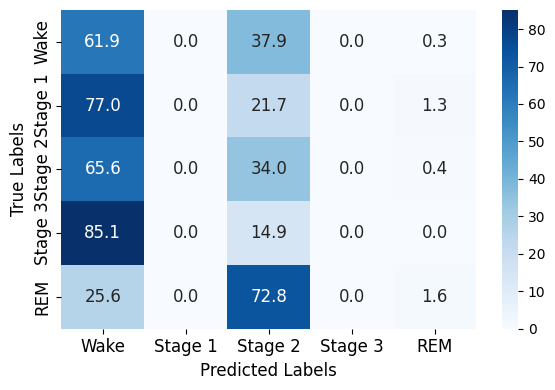

In [92]:
# Step 1: Get predicted labels (argmax on probabilities)
predicted_labels = np.argmax(all_outputs_filtered, axis=1)

fontsize = 12

# Step 2: Compute F1 score for each class
f1_scores = f1_score(all_targets_filtered, predicted_labels, average=None, labels=range(len(class_labels)))
for idx, label in enumerate(class_labels):
    print(f"F1 Score for {label}: {f1_scores[idx]:.3f}")

# Step 3: Create a confusion matrix and normalize it by row to get percentages
conf_matrix = confusion_matrix(all_targets_filtered, predicted_labels, labels=range(len(class_labels)))
conf_matrix_percent = conf_matrix / conf_matrix.sum(axis=1, keepdims=True) * 100

# Plotting the confusion matrix with percentages
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix_percent,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
    annot_kws={"size": fontsize},  # Font size for numbers inside the heatmap
    cbar_kws={"shrink": 1},  # Adjust colorbar size
)

# Customizing axis labels and ticks
plt.xlabel("Predicted Labels", fontsize=fontsize)
plt.ylabel("True Labels", fontsize=fontsize)
plt.xticks(fontsize=12, ha="center")  # Font size for x-axis tick labels with rotation
plt.yticks(fontsize=12)  # Font size for y-axis tick labels

# Adjust layout and save the figure
plt.tight_layout()
plt.show()

In [93]:
import numpy as np
import torch  # PyTorch 사용 기준 (TensorFlow 사용 시 np.array 변환 적용)

print("=" * 50)
print("1. 클래스별 데이터 개수 및 비율 확인 (Class Imbalance Check)")
print("=" * 50)
# 진단 코드 가장 맨 위에 이 줄을 추가해주시면 안전합니다.
all_targets_filtered = np.array(all_targets_filtered, dtype=int)
# 실제 정답 라벨의 클래스별 개수 집계
unique_classes, counts = np.unique(all_targets_filtered, return_counts=True)
total_samples = len(all_targets_filtered)

# 수정된 루프 코드 (int(cls) 적용)
for cls, count in zip(unique_classes, counts):
    cls_int = int(cls)  # numpy.float32를 int로 변환
    label_name = (
        class_labels[cls_int]
        if cls_int < len(class_labels)
        else f"Class {cls_int}"
    )
    percentage = (count / total_samples) * 100
    print(
        f"Label [{cls_int}] ({label_name}): {count:6d}개 ({percentage:5.2f}%)"
    )
print("\n" + "=" * 50)
print("2. 모델 출력값(Output Shape & Probability) 상태 확인")
print("=" * 50)

# 출력 데이터의 Shape 확인
print(f"all_outputs_filtered Shape: {all_outputs_filtered.shape}")
print(f"all_targets_filtered Shape: {all_targets_filtered.shape}")

# 상위 5개 샘플에 대한 소프트맥스 확률값 및 예측 결과 출력
# (만약 logits 상태라면 Softmax 적용)
if np.max(all_outputs_filtered) > 1.0 or np.min(all_outputs_filtered) < 0.0:
    # PyTorch 기준 Softmax 계산 예시
    probs = (
        torch.softmax(torch.tensor(all_outputs_filtered), dim=1).numpy()
        if isinstance(all_outputs_filtered, (np.ndarray, list))
        else all_outputs_filtered
    )
else:
    probs = all_outputs_filtered

print("\n[상위 5개 샘플의 클래스별 예측 확률(%)]")
for i in range(min(5, len(probs))):
    prob_percent = probs[i] * 100
    pred_cls = np.argmax(prob_percent)
    true_cls = all_targets_filtered[i]
    print(f"Sample {i+1}:")
    print(
        f"  - 실제 정답: {class_labels[true_cls]} (Class {true_cls})"
    )
    print(
        f"  - 모델 예측: {class_labels[pred_cls]} (Class {pred_cls})"
    )
    print(
        f"  - 각 클래스 확률: {np.array2string(prob_percent, precision=1, suppress_small=True)}"
    )

print("\n" + "=" * 50)
print("3. 전체 샘플에 대한 클래스별 평균 예측 확률")
print("=" * 50)

# 전체 데이터 세트에 대해 모델이 각 클래스일 확률을 평균 몇 %로 내고 있는지 확인
mean_probs = np.mean(probs, axis=0) * 100
for idx, label in enumerate(class_labels):
    print(f"Average Probability for {label:7s}: {mean_probs[idx]:5.2f}%")

1. 클래스별 데이터 개수 및 비율 확인 (Class Imbalance Check)
Label [0] (Wake):    396개 ( 8.39%)
Label [1] (Stage 1):    318개 ( 6.73%)
Label [2] (Stage 2):   2130개 (45.11%)
Label [3] (Stage 3):    624개 (13.21%)
Label [4] (REM):   1254개 (26.56%)

2. 모델 출력값(Output Shape & Probability) 상태 확인
all_outputs_filtered Shape: (4722, 5)
all_targets_filtered Shape: (4722,)

[상위 5개 샘플의 클래스별 예측 확률(%)]
Sample 1:
  - 실제 정답: Wake (Class 0)
  - 모델 예측: Wake (Class 0)
  - 각 클래스 확률: [92.9  1.   3.5  1.4  1.2]
Sample 2:
  - 실제 정답: Wake (Class 0)
  - 모델 예측: Wake (Class 0)
  - 각 클래스 확률: [96.   1.5  1.7  0.4  0.4]
Sample 3:
  - 실제 정답: Wake (Class 0)
  - 모델 예측: Wake (Class 0)
  - 각 클래스 확률: [97.7  0.6  1.1  0.3  0.3]
Sample 4:
  - 실제 정답: Wake (Class 0)
  - 모델 예측: Wake (Class 0)
  - 각 클래스 확률: [98.6  0.5  0.6  0.2  0.1]
Sample 5:
  - 실제 정답: Wake (Class 0)
  - 모델 예측: Wake (Class 0)
  - 각 클래스 확률: [99.3  0.3  0.3  0.1  0.1]

3. 전체 샘플에 대한 클래스별 평균 예측 확률
Average Probability for Wake   : 45.80%
Average Probability for Stage 1:  9.17%
A

#### Part 3: Disease Prediction

제3부: 질병 예측
질병예측에 주어야되는 것들이 피험자 나이랑 성별, 지금 확인해본 결과, 17 데이터셋에 성별은 존재, 나이가 없음


In [71]:
disease_model_path = "../sleepfm/checkpoints/model_diagnosis"
config = load_data(os.path.join(disease_model_path, "config.json"))
print(config)

{'model_params': {'embed_dim': 128, 'num_heads': 8, 'num_layers': 2, 'num_classes': 1065, 'pooling_head': 8, 'dropout': 0.3, 'max_seq_length': 6480}, 'max_channels': 4, 'chunk_size': 60, 'seed': 42, 'model': 'DiagnosisFinetuneFullLSTMCOXPHWithDemo', 'dataset': 'ssc_stanford', 'batch_size': 32, 'epochs': 40, 'lr': 0.001, 'num_workers': 7, 'model_path': 'sleepfm/checkpoints/model_base', 'split_path': 'sleepfm/configs/dataset_split.json', 'labels_path': 'path/to/time/to/event/files', 'demo_labels_path': 'notebooks/demo_age_gender.csv', 'save_iter': 100, 'eval_iter': 100, 'log_interval': 10, 'accumulation_steps': 16, 'use_wandb': False, 'max_files': None, 'sampling_freq': 128, 'modality_types': ['BAS', 'RESP', 'EKG', 'EMG']}


In [72]:
# 뇌파(BAS) 6채널 환경에 맞춰 config 수정
config['modality_types'] = ['BAS']
config['max_channels'] = 6

# (필요시) Windows 환경 멀티프로세싱 에러 방지를 위해 num_workers 조정
# config['num_workers'] = 1

print(config)

{'model_params': {'embed_dim': 128, 'num_heads': 8, 'num_layers': 2, 'num_classes': 1065, 'pooling_head': 8, 'dropout': 0.3, 'max_seq_length': 6480}, 'max_channels': 6, 'chunk_size': 60, 'seed': 42, 'model': 'DiagnosisFinetuneFullLSTMCOXPHWithDemo', 'dataset': 'ssc_stanford', 'batch_size': 32, 'epochs': 40, 'lr': 0.001, 'num_workers': 7, 'model_path': 'sleepfm/checkpoints/model_base', 'split_path': 'sleepfm/configs/dataset_split.json', 'labels_path': 'path/to/time/to/event/files', 'demo_labels_path': 'notebooks/demo_age_gender.csv', 'save_iter': 100, 'eval_iter': 100, 'log_interval': 10, 'accumulation_steps': 16, 'use_wandb': False, 'max_files': None, 'sampling_freq': 128, 'modality_types': ['BAS']}


In [ ]:
# 수면 단계 분류용 config 업데이트
sleep_staging_config['channel_like'] = ['BAS']
sleep_staging_config['max_channels'] = 6

# (필요시) num_workers도 윈도우 환경 안정성을 위해 줄여줄 수 있습니다.
# sleep_staging_config['num_workers'] = 1 

print(sleep_staging_config)

In [73]:
print(config)

{'model_params': {'embed_dim': 128, 'num_heads': 8, 'num_layers': 2, 'num_classes': 1065, 'pooling_head': 8, 'dropout': 0.3, 'max_seq_length': 6480}, 'max_channels': 6, 'chunk_size': 60, 'seed': 42, 'model': 'DiagnosisFinetuneFullLSTMCOXPHWithDemo', 'dataset': 'ssc_stanford', 'batch_size': 32, 'epochs': 40, 'lr': 0.001, 'num_workers': 7, 'model_path': 'sleepfm/checkpoints/model_base', 'split_path': 'sleepfm/configs/dataset_split.json', 'labels_path': 'path/to/time/to/event/files', 'demo_labels_path': 'notebooks/demo_age_gender.csv', 'save_iter': 100, 'eval_iter': 100, 'log_interval': 10, 'accumulation_steps': 16, 'use_wandb': False, 'max_files': None, 'sampling_freq': 128, 'modality_types': ['BAS']}


In [74]:
config["model_params"]["dropout"] = 0.0
model_params = config['model_params']
model_class = getattr(sys.modules[__name__], config['model'])
model = model_class(**model_params).to(device)
model_name = type(model).__name__

In [75]:
model = nn.DataParallel(model)
print(f"Model initialized: {model_name}")
total_layers, total_params = count_parameters(model)
print(f'Trainable parameters: {total_params / 1e6:.2f} million')
print(f'Number of layers: {total_layers}')

Model initialized: DiagnosisFinetuneFullLSTMCOXPHWithDemo
Trainable parameters: 0.91 million
Number of layers: 15


In [76]:
checkpoint_path = os.path.join(disease_model_path, "best.pth")

In [77]:
checkpoint = torch.load(checkpoint_path)
model.load_state_dict(checkpoint)

C:\Users\user\AppData\Local\Temp\ipykernel_25216\2254764488.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


<All keys matched successfully>

In [78]:
class DiagnosisFinetuneFullCOXPHWithDemoDataset(Dataset):
    def __init__(self, 
                 config,
                 channel_groups,
                 hdf5_paths=None,
                 demo_labels_path=None,
                 split="train"):

        self.config = config
        self.channel_groups = channel_groups
        self.max_channels = self.config["max_channels"]

        # --- Load demographic features ---
        if not demo_labels_path:
            demo_labels_path = config["demo_labels_path"]

        demo_labels_df = pd.read_csv(demo_labels_path)
        demo_labels_df = demo_labels_df.set_index("Study ID")
        study_ids = set(demo_labels_df.index)

        is_event_df = pd.read_csv(os.path.join(self.config["labels_path"], "is_event.csv"))
        event_time_df = pd.read_csv(os.path.join(self.config["labels_path"], "time_to_event.csv"))

        is_event_df = is_event_df.set_index('Study ID')
        event_time_df = event_time_df.set_index('Study ID')

        # --- Resolve HDF5 paths (explicit precedence) ---
        if hdf5_paths:
            # Use provided paths directly
            hdf5_paths = [f for f in hdf5_paths if os.path.exists(f)]
        else:
            # Load from split file
            split_paths = load_data(config["split_path"])[split]
            hdf5_paths = [f for f in split_paths if os.path.exists(f)]

        # Filter by available demo labels
        hdf5_paths = [
            f for f in hdf5_paths
            if os.path.basename(f).split(".")[0] in study_ids
        ]

        # Optional truncation
        if config.get("max_files"):
            hdf5_paths = hdf5_paths[:config["max_files"]]

        labels_dict = {}
        # Loop over each study_id
        for study_id in tqdm.tqdm(study_ids):
            # Extract the row as a whole for both dataframes (faster than iterating over columns)
            is_event_row = list(is_event_df.loc[study_id].values)
            event_time_row = list(event_time_df.loc[study_id].values)
            demo_feats = list(demo_labels_df.loc[study_id].values)

            # values = [[event_time, is_event] for is_event, event_time in zip(is_event_row, event_time_row)]
            labels_dict[study_id] = {
                "is_event": is_event_row,
                "event_time": event_time_row, 
                "demo_feats": demo_feats
            }

        # --- Build index map ---
        self.index_map = [
            (path, labels_dict[os.path.basename(path).split(".")[0]])
            for path in hdf5_paths
        ]

        print(f"Number of files in {split} set: {len(hdf5_paths)}")
        print(f"Number of files to be processed in {split} set: {len(self.index_map)}")

        self.total_len = len(self.index_map)
        self.max_seq_len = config["model_params"]["max_seq_length"]

        if self.total_len == 0:
            raise ValueError(f"No valid HDF5 files found for split='{split}'.")

    def __len__(self):
        return self.total_len

    def __getitem__(self, idx):
        hdf5_path, tte_event = self.index_map[idx]

        event_time = tte_event["event_time"]
        is_event = tte_event["is_event"]
        demo_feats = tte_event["demo_feats"]

        x_data = []
        with h5py.File(hdf5_path, 'r') as hf:
            dset_names = []
            for dset_name in hf.keys():
                if isinstance(hf[dset_name], h5py.Dataset) and dset_name in self.config["modality_types"]:
                    dset_names.append(dset_name)
            
            random.shuffle(dset_names)
            for dataset_name in dset_names:
                x_data.append(hf[dataset_name][:])

        if not x_data:
            # Skip this data point if x_data is empty
            return self.__getitem__((idx + 1) % self.total_len)

        # Convert x_data list to a single numpy array
        x_data = np.array(x_data)

        # Convert x_data to tensor
        x_data = torch.tensor(x_data, dtype=torch.float32)

        event_time = torch.tensor(event_time, dtype=torch.float32)
        is_event = torch.tensor(is_event) 

        demo_feats = torch.tensor(demo_feats, dtype=torch.float32)

        return x_data, event_time, is_event, demo_feats, self.max_channels, self.max_seq_len, hdf5_path


def diagnosis_finetune_full_coxph_with_demo_collate_fn(batch):
    x_data, event_time, is_event, demo_feats, max_channels_list, max_seq_len_list, hdf5_path_list = zip(*batch)

    num_channels = max(max_channels_list)

    if max_seq_len_list[0] == None:
        max_seq_len = max([item.size(1) for item in x_data])
    else:
        max_seq_len = max_seq_len_list[0]

    padded_x_data = []
    padded_mask = []
    for item in x_data:
        c, s, e = item.size()
        c = min(c, num_channels)
        s = min(s, max_seq_len)  # Ensure the sequence length doesn't exceed max_seq_len

        # Create a padded tensor and a mask tensor
        padded_item = torch.zeros((num_channels, max_seq_len, e))
        mask = torch.ones((num_channels, max_seq_len))

        # Copy the actual data to the padded tensor and set the mask for real data
        padded_item[:c, :s, :e] = item[:c, :s, :e]
        mask[:c, :s] = 0  # 0 for real data, 1 for padding

        padded_x_data.append(padded_item)
        padded_mask.append(mask)
    
    # Stack all tensors into a batch
    x_data = torch.stack(padded_x_data)
    event_time = torch.stack(event_time)
    is_event = torch.stack(is_event)
    demo_feats = torch.stack(demo_feats)
    padded_mask = torch.stack(padded_mask)
    
    return x_data, event_time, is_event, demo_feats, padded_mask, hdf5_path_list

In [79]:
save_path = os.path.join(base_save_path, "demo_diagnosis")
os.makedirs(save_path, exist_ok=True)

In [80]:
hdf5_paths = [os.path.join(base_save_path, "demo_emb/demo_psg.hdf5")]
demo_labels_path = os.path.join(base_save_path, "demo_age_gender.csv")
config["labels_path"] = base_save_path

test_dataset = DiagnosisFinetuneFullCOXPHWithDemoDataset(config, channel_groups, split="test", hdf5_paths=hdf5_paths, demo_labels_path=demo_labels_path)

FileNotFoundError: [Errno 2] No such file or directory: 'demo_data\\sub-001\\ses-001\\eeg\\demo_age_gender.csv'

In [51]:
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0, collate_fn=diagnosis_finetune_full_coxph_with_demo_collate_fn)

In [52]:
model.eval()
all_event_times = []
all_is_event = []
all_outputs = []
all_paths = []

with torch.no_grad():
    for item in tqdm.tqdm(test_loader, desc="Evaluating"):
        x_data, event_times, is_event, demo_feats, padded_matrix, hdf5_path_list = item
        x_data, event_times, is_event, demo_feats, padded_matrix, hdf5_path_list = x_data.to(device), event_times.to(device), is_event.to(device), demo_feats.to(device), padded_matrix.to(device), list(hdf5_path_list)
        outputs = model(x_data, padded_matrix, demo_feats)
    
        logits = outputs.cpu().numpy()
        all_outputs.append(logits)
        all_event_times.append(event_times.cpu().numpy())
        all_is_event.append(is_event.cpu().numpy())
        all_paths.append(hdf5_path_list)

all_outputs = np.concatenate(all_outputs, axis=0)
all_event_times = np.concatenate(all_event_times, axis=0)
all_is_event = np.concatenate(all_is_event, axis=0)
all_paths = np.concatenate(all_paths)

outputs_path = os.path.join(save_path, "all_outputs.pickle")
event_times_path = os.path.join(save_path, "all_event_times.pickle")
is_event_path = os.path.join(save_path, "all_is_event.pickle")
file_paths = os.path.join(save_path, "all_paths.pickle")

save_data(all_outputs, outputs_path)
save_data(all_event_times, event_times_path)
save_data(all_is_event, is_event_path)
save_data(all_paths, file_paths)

Evaluating: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.41it/s]


In [53]:
all_outputs.shape, all_event_times.shape, all_is_event.shape

((1, 1065), (1, 1065), (1, 1065))

Above, you get the model outputs, which you can then use to look for specific disease diagnosis. Nope that the shape of the output above is 1065, meaning, this model gives logprobs for 1065 conditions. We provide information about each disease index and its corresponding phecode here `sleepfm/configs/label_mapping.csv`. You can map it as follows. 

In [54]:
labels_df = pd.read_csv("../sleepfm/configs/label_mapping.csv")

In [55]:
labels_df["output"] = all_outputs[0]
labels_df["is_event"] = all_is_event[0]
labels_df["event_time"] = all_event_times[0]

In [56]:
labels_df.head()

,label_idx,phecode,phenotype,output,is_event,event_time
0,0,8.0,Intestinal infection,2.382425,0,3845.0
1,1,8.5,Bacterial enteritis,2.941730,0,3845.0
2,2,8.6,Viral Enteritis,3.220654,0,3845.0
3,3,38.0,Septicemia,5.640564,0,3845.0
4,4,38.3,Bacteremia,5.597531,0,3845.0


Above, you get the output hazards from our model, and also your labels for is_event and event_times. Is_event is an indicator for if the event occured and event_time is the time to event